# 02 - Model Eğitimi: Linear Regression ve Random Forest
Bu notebook'ta sliding window yöntemi ile oluşturulan zaman serisi verisi üzerinde
temel makine öğrenmesi modelleri eğitilmekte ve performansları karşılaştırılmaktadır.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../data/raw/request_level_data.csv")

print(f"Veri boyutu: {df.shape}")
df.head()

Veri boyutu: (29209, 14)


,request_id,timestamp,scenario,endpoint_name,endpoint_path,payload_size,response_time_ms,status_code,active_requests,rps_10s,requests_last_60s,client_send_ts,client_receive_ts,client_observed_latency_ms
0,1,2026-04-18T14:40:11.827719,low,users,/api/users,316,192.81,200,1,0.1,1,2026-04-18T14:40:11.611374,2026-04-18T14:40:11.827719,213.20
1,2,2026-04-18T14:40:11.915110,low,search,/api/search,340,288.12,200,3,0.3,3,2026-04-18T14:40:11.611374,2026-04-18T14:40:11.915110,293.71
2,3,2026-04-18T14:40:11.733971,low,users,/api/users,296,104.07,200,2,0.2,2,2026-04-18T14:40:11.611374,2026-04-18T14:40:11.733971,112.62
3,4,2026-04-18T14:40:13.286060,low,orders,/api/orders,871,346.18,200,1,0.4,4,2026-04-18T14:40:12.915854,2026-04-18T14:40:13.286060,371.32
4,5,2026-04-18T14:40:13.254810,low,reports,/api/reports,387,314.19,200,2,0.5,5,2026-04-18T14:40:12.915854,2026-04-18T14:40:13.254810,339.68


## Veri Ön İşleme

Zaman bilgisi dönüştürülmüş ve veri kronolojik sıraya göre düzenlenmiştir.

In [2]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

## Feature Seçimi

Model girişinde sistem yükünü temsil eden değişkenler kullanılmıştır.
Tahmin edilecek değişken: response_time_ms

In [3]:
features = ["payload_size", "active_requests", "rps_10s", "requests_last_60s"]
target = "response_time_ms"

print("Kullanılan feature'lar:", features)
print("Hedef değişken:", target)

Kullanılan feature'lar: ['payload_size', 'active_requests', 'rps_10s', 'requests_last_60s']
Hedef değişken: response_time_ms


## Sliding Window Uygulaması

Zaman bağımlılıklarını modele dahil etmek için sliding window yöntemi kullanılmaktadır.
Her giriş, son `window_size` zaman adımındaki feature değerlerini içermektedir.

In [13]:
def create_window(df, features, target, window_size):
    X, y = [], []
    
    for i in range(len(df) - window_size):
        X.append(df[features].iloc[i:i+window_size].values)
        y.append(df[target].iloc[i+window_size])
    
    return np.array(X), np.array(y)

WINDOW_SIZE = 10

X, y = create_window(df, features, target, window_size)

# Sklearn modelleri için 2D'ye düzleştir
X_flat = X.reshape(X.shape[0], -1)

print(f"X_flat shape: {X_flat.shape}")
print(f"y shape: {y.shape}")

X_flat shape: (29199, 40)
y shape: (29199,)


## Train-Test Ayrımı

Zaman serisi verisi olduğundan shuffle yapılmadan kronolojik sırayla ayrım yapılmaktadır.

In [7]:
split = int(len(X_flat) * 0.8)

X_train, X_test = X_flat[:split], X_flat[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (23359, 40), Test: (5840, 40)


## Linear Regression Modeli

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Linear Regression eğitimi tamamlandı.")

Linear Regression eğitimi tamamlandı.


## Random Forest Modeli

In [9]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest eğitimi tamamlandı.")

Random Forest eğitimi tamamlandı.


## Model Performans Değerlendirmesi

In [10]:
def evaluate(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "MAE":  round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "R2":   round(r2_score(y_true, y_pred), 4)
    }

lr_results = evaluate(y_test, y_pred_lr, "Linear Regression")
rf_results = evaluate(y_test, y_pred_rf, "Random Forest")

results_df = pd.DataFrame([lr_results, rf_results]).set_index("Model")
print(results_df.to_string())
results_df

                      MAE    RMSE      R2
Model                                    
Linear Regression  147.21  196.44  0.0242
Random Forest      146.37  196.56  0.0230


,MAE,RMSE,R2
Model,,,
Linear Regression,147.21,196.44,0.0242
Random Forest,146.37,196.56,0.0230


## Tahmin Sonuçlarının Görselleştirilmesi

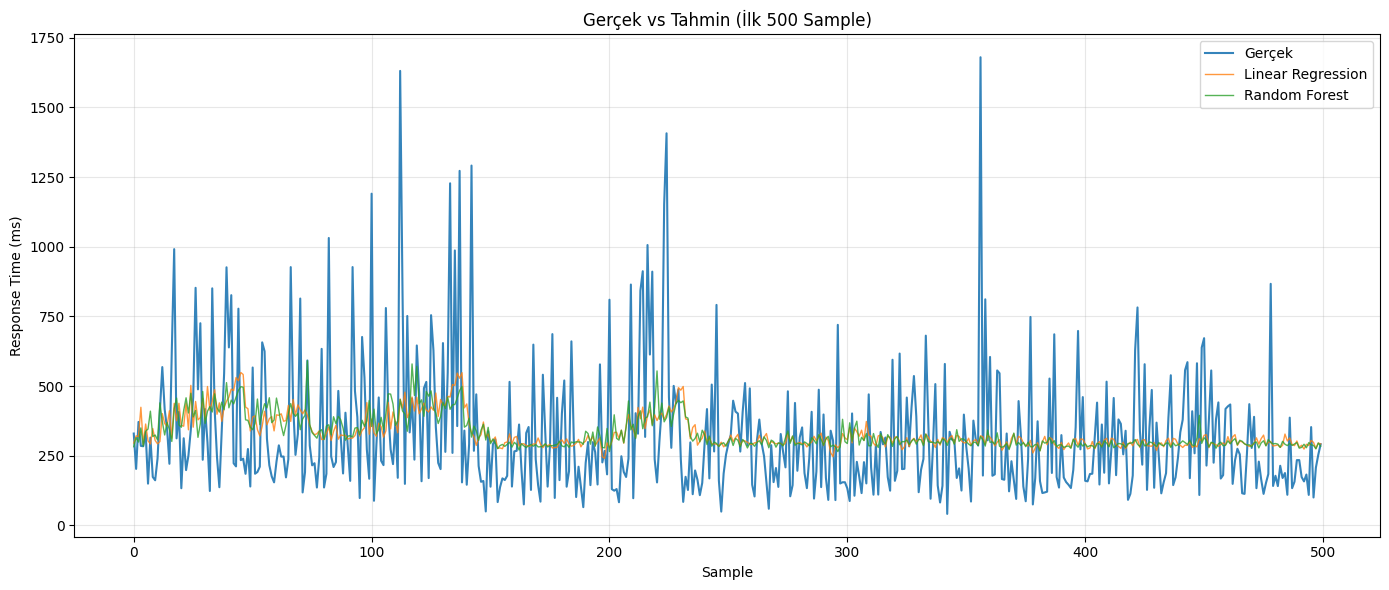

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(y_test[:500], label="Gerçek", linewidth=1.5, alpha=0.9)
plt.plot(y_pred_lr[:500], label="Linear Regression", linewidth=1, alpha=0.8)
plt.plot(y_pred_rf[:500], label="Random Forest", linewidth=1, alpha=0.8)
plt.title("Gerçek vs Tahmin (İlk 500 Sample)")
plt.xlabel("Sample")
plt.ylabel("Response Time (ms)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

os.makedirs("../outputs", exist_ok=True)
plt.savefig("../outputs/lr_rf_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

Gerçek ve tahmin değerlerinin karşılaştırıldığı grafik incelendiğinde, modellerin genel trendi yakalayabildiği ancak ani yükselişleri (spike) tahmin etmekte yetersiz kaldığı görülmektedir. Özellikle yüksek gecikme değerlerinde model hatalarının arttığı gözlemlenmiştir.

### Model Kaydetme

In [14]:
models_path = "../models"
os.makedirs(models_path, exist_ok=True)

joblib.dump(rf, os.path.join(models_path, "random_forest_model.pkl"))
joblib.dump(lr, os.path.join(models_path, "linear_regression_model.pkl"))

config = {
    "features": features,
    "target": target,
    "window_size": WINDOW_SIZE
}
joblib.dump(config, os.path.join(models_path, "model_config.pkl"))

print("Modeller kaydedildi:")
print(f"  {models_path}/random_forest_model.pkl")
print(f"  {models_path}/linear_regression_model.pkl")
print(f"  {models_path}/model_config.pkl")

Modeller kaydedildi:
  ../models/random_forest_model.pkl
  ../models/linear_regression_model.pkl
  ../models/model_config.pkl
